<a href="https://colab.research.google.com/github/SaadS315/EDA/blob/main/lab/DS3001_Extra_Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Reading in the csv using pandas.
df = pd.read_csv("EDA_Lab.csv")

# Taking a look at what it looks like.
df.head()

,year,id_,age,educ,paeduc,maeduc,sex,race
0,1972,1,23,4 years of college,10th grade,.i: Inapplicable,FEMALE,White
1,1972,2,70,10th grade,8th grade,8th grade,MALE,White
2,1972,3,48,12th grade,8th grade,8th grade,FEMALE,White
3,1972,4,27,5 years of college,4 years of college,12th grade,FEMALE,White
4,1972,5,61,12th grade,8th grade,8th grade,FEMALE,White


In [23]:
df["educ"].value_counts()

# Education years are not in the correct number format and need to be changed. I will start from 3rd grade.

education_map = {
    "3rd grade": 3,
    "4th grade": 4,
    "5th grade": 5,
    "6th grade": 6,
    "7th grade": 7,
    "8th grade": 8,
    "9th grade": 9,
    "10th grade": 10,
    "11th grade": 11,
    "12th grade": 12,
    "1 year of college": 13,
    "2 years of college": 14,
    "3 years of college": 15,
    "4 years of college": 16,
    "5 years of college": 17,
    "6 years of college": 18,
    "7 years of college": 19,
    "8 or more years of college": 20
}

paeduc_map = {
    "3rd grade": 3,
    "4th grade": 4,
    "5th grade": 5,
    "6th grade": 6,
    "7th grade": 7,
    "8th grade": 8,
    "9th grade": 9,
    "10th grade": 10,
    "11th grade": 11,
    "12th grade": 12,
    "1 year of college": 13,
    "2 years of college": 14,
    "3 years of college": 15,
    "4 years of college": 16,
    "5 years of college": 17,
    "6 years of college": 18,
    "7 years of college": 19,
    "8 or more years of college": 20
}

maeduc_map = {
    "3rd grade": 3,
    "4th grade": 4,
    "5th grade": 5,
    "6th grade": 6,
    "7th grade": 7,
    "8th grade": 8,
    "9th grade": 9,
    "10th grade": 10,
    "11th grade": 11,
    "12th grade": 12,
    "1 year of college": 13,
    "2 years of college": 14,
    "3 years of college": 15,
    "4 years of college": 16,
    "5 years of college": 17,
    "6 years of college": 18,
    "7 years of college": 19,
    "8 or more years of college": 20
}

df['educ_years'] = df['educ'].map(education_map)
df["paeduc_years"] =  df['paeduc'].map(paeduc_map)
df["maeduc_years"] =  df['maeduc'].map(paeduc_map)

df = df.dropna(subset=['educ_years'])
df = df.dropna(subset=['paeduc_years'])
df = df.dropna(subset=['maeduc_years'])

df.describe()

,year,id_,educ_years,paeduc_years,maeduc_years
count,47844.000000,47844.000000,47844.000000,47844.000000,47844.000000
mean,1999.158599,1247.785260,13.826122,11.504138,11.624843
std,15.786098,900.070075,2.813038,3.842172,3.179408
min,1972.000000,1.000000,3.000000,3.000000,3.000000
25%,1986.000000,543.000000,12.000000,8.000000,10.000000
50%,1998.000000,1093.000000,14.000000,12.000000,12.000000
75%,2014.000000,1748.250000,16.000000,14.000000,13.000000
max,2024.000000,4509.000000,20.000000,20.000000,20.000000


Text(0.5, 1.0, 'Years of Education')

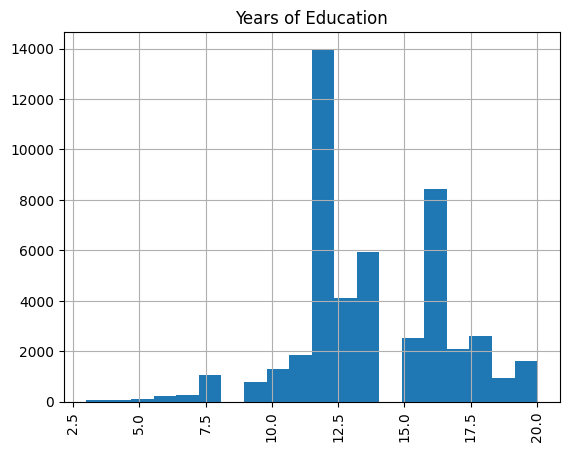

In [24]:
df.shape # Shape is (44398, 8)

df["educ"].value_counts()

df["educ_years"].hist(bins = 20)
plt.xticks(rotation = 90)
plt.title("Years of Education")



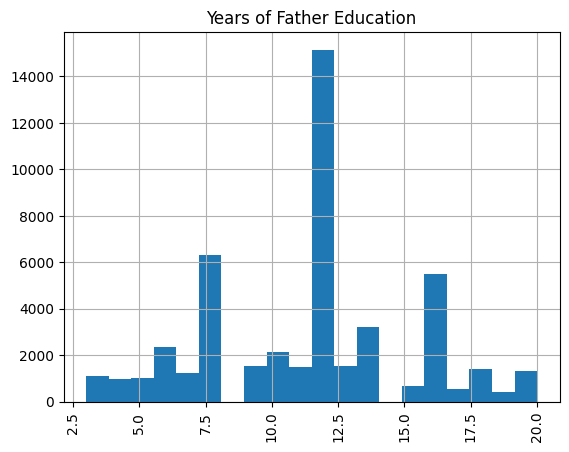

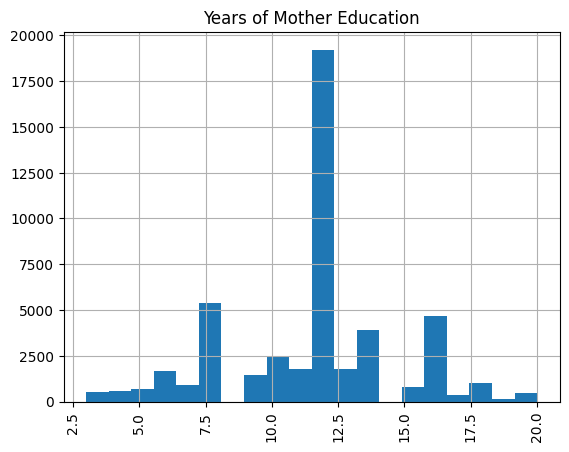

In [25]:
df['paeduc_years'].hist(bins=20)
plt.xticks(rotation = 90)
plt.title("Years of Father Education")
plt.show()


df['maeduc_years'].hist(bins=20)
plt.xticks(rotation = 90)
plt.title("Years of Mother Education")
plt.show()


In [27]:
print(df.groupby('sex')['educ_years'].mean()) # Relationship betwen sex and education years
print(df.groupby('race')['educ_years'].mean()) # Relationship between race and education years


df[['educ_years','paeduc_years','maeduc_years']].corr() # Core correlation

sex
.d:  Do not Know/Cannot Choose    10.000000
.i:  Inapplicable                 14.000000
.n:  No answer                    14.040000
.s:  Skipped on Web               14.166667
FEMALE                            13.728560
MALE                              13.944437
Name: educ_years, dtype: float64
race
.i:  Inapplicable    14.956989
Black                13.263238
Other                14.264927
White                13.860352
Name: educ_years, dtype: float64


,educ_years,paeduc_years,maeduc_years
educ_years,1.000000,0.433136,0.419579
paeduc_years,0.433136,1.000000,0.636932
maeduc_years,0.419579,0.636932,1.000000


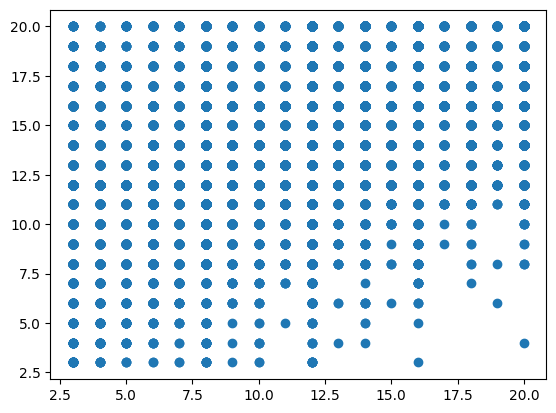

In [28]:
plt.scatter(df['paeduc_years'], df['educ_years'])

In [29]:
pd.crosstab(df['race'], df['sex']) # Getting an idea of the race and sex in this dataset.

sex,.d: Do not Know/Cannot Choose,.i: Inapplicable,.n: No answer,.s: Skipped on Web,FEMALE,MALE
race,,,,,,
.i: Inapplicable,0,3,1,0,54,35
Black,1,1,3,0,2812,1810
Other,2,1,6,3,1312,1205
White,3,2,15,3,21953,18619


In [30]:
pd.crosstab(df['race'], df['educ_years'])

educ_years,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0
race,,,,,,,,,,,,,,,,,,
.i: Inapplicable,0,0,0,2,0,0,0,0,4,14,8,12,6,25,7,5,4,6
Black,9,21,23,43,37,73,113,164,279,1341,509,692,281,591,124,170,60,97
Other,4,8,5,42,13,45,45,51,98,480,204,324,158,573,126,160,57,136
White,37,41,59,145,209,932,620,1083,1460,12125,3402,4909,2075,7222,1815,2273,826,1362


In [31]:
df[['educ_years','paeduc_years','maeduc_years']].mean()

,0
educ_years,13.826122
paeduc_years,11.504138
maeduc_years,11.624843


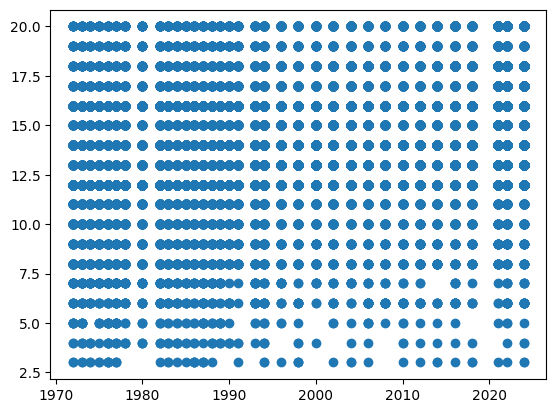

In [34]:
plt.scatter(df["year"], df["educ_years"]) # Very cluttered. Not the best way to look at this information.

Text(0.5, 1.0, "Education versus Father's Education")

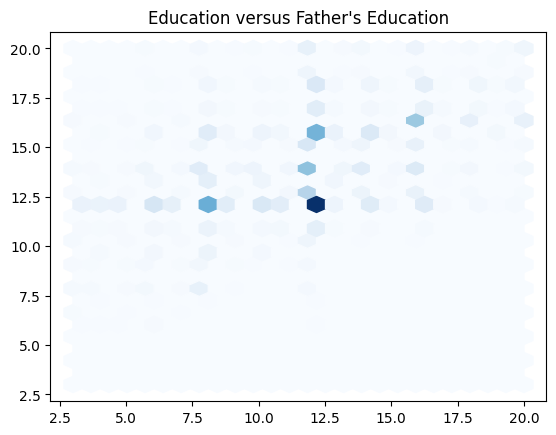

In [33]:
# trying hexbin

plt.hexbin(df['paeduc_years'], df['educ_years'], gridsize=25, cmap='Blues')
plt.title("Education versus Father's Education")

Text(0.5, 1.0, "Education versus Mother's Education")

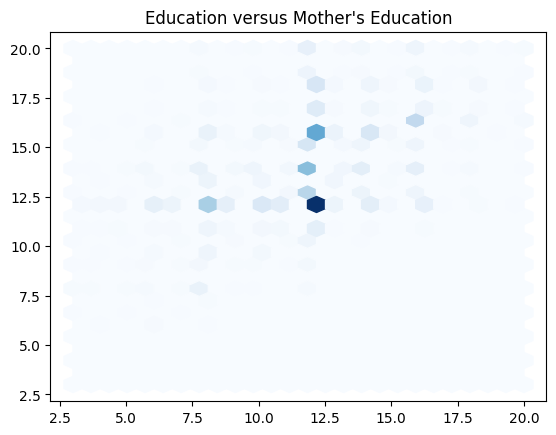

In [35]:
plt.hexbin(df['maeduc_years'], df['educ_years'], gridsize=25, cmap='Blues')
plt.title("Education versus Mother's Education")

Text(0.5, 1.0, 'Education Distribution by Race')

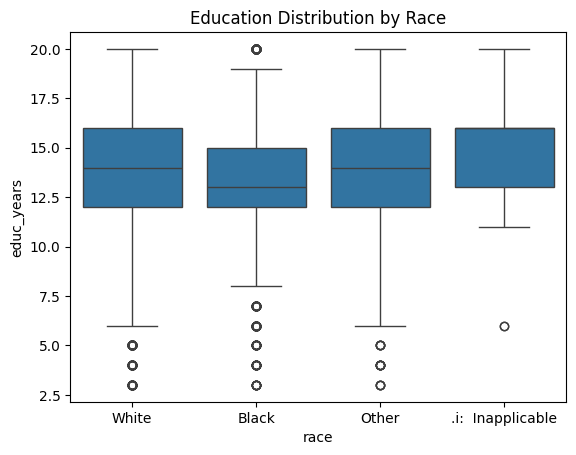

In [36]:
sns.boxplot(x = "race", y = "educ_years", data = df)
plt.title("Education Distribution by Race")

In [37]:
df["sex"].value_counts() # There are some categories like "skipped on web" or inapplicable that should be removed.


,count
sex,
FEMALE,26131
MALE,21669
.n: No answer,25
.i: Inapplicable,7
.s: Skipped on Web,6
.d: Do not Know/Cannot Choose,6


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'MALE'),
  Text(1, 0, 'FEMALE'),
  Text(2, 0, '.i:  Inapplicable'),
  Text(3, 0, '.n:  No answer'),
  Text(4, 0, '.s:  Skipped on Web'),
  Text(5, 0, '.d:  Do not Know/Cannot Choose')])

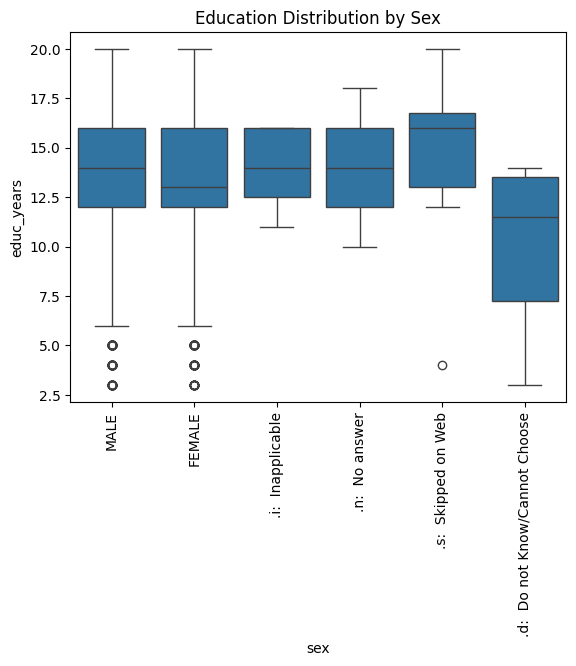

In [38]:
sns.boxplot(x = "sex", y = "educ_years", data = df)
plt.title("Education Distribution by Sex") # Doesn't look very good so I will rotate the axis so every category shows.
plt.xticks(rotation = 90)